# Intrinsic Volume Approximations with Real Flag Matrix Manifolds and Matern Kernels

In [1]:
import rmatqmcpy 
import torch
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
import scipy
from matplotlib import pyplot
torch.set_default_dtype(torch.float64)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)

torch device = cpu
MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12


In [2]:
body = "cube" # cube,random
p = 4 # 2,3
n = 5 # 3,5
nu = 3/2 # 3/2,5/2
log2_N_ref = 25
log2_N_max = 11 # 12,11
log2_N_rho = 11
trials = 100
assert n>p
print("n = %d"%n)
print("nu = %.1f"%nu)
print("log2_N_ref = %d"%log2_N_ref)
print("log2_N_max = %s"%log2_N_max)
print("log2_N_rho = %s"%log2_N_rho)
if body=="cube": # cube [-1,1]^n
    Z = torch.tensor([[2*int(b)-1 for b in np.binary_repr(k,width=n)] for k in range(2**n)],dtype=float,device=DEVICE)
    Tk_true = (agsutil.comb(torch.tensor(n,device=DEVICE),torch.arange(n+1,device=DEVICE))*2**torch.arange(n+1,device=DEVICE))[:(1+p)]
elif body=="random": # convex hull of random normal points
    Z = torch.randn(10,n,device=DEVICE)
    Tk_true = torch.nan*torch.ones(n+1,device=DEVICE)
else: raise Exception("invalid body = %s"%body)
print("Z.shape = %s"%str(tuple(Z.shape)))
print("Z = \n%s"%str(Z))
print("Tk_true = %s"%Tk_true)
nvec = torch.arange(n+1,device=DEVICE)
logkappa = (nvec/2)*np.log(np.pi)-torch.lgamma(nvec/2+1)
print("logkappa.shape = %s"%str(tuple(logkappa.shape)))
print("kappa = torch.exp(logkappa) = %s"%torch.exp(logkappa))
coeff_Tk = torch.exp(agsutil.logcomb(nvec[-1],nvec)+logkappa[-1]-logkappa-torch.flip(logkappa,dims=(0,)))
print("coeff_Tk.shape = %s"%str(tuple(coeff_Tk.shape)))
print("coeff_Tk = %s"%coeff_Tk)
delta = torch.tensor([max(p+1-i,1) for i in range(n)],device=DEVICE,dtype=float)
delta = delta/torch.linalg.norm(delta)
_,_inv_m,m = delta.unique(return_inverse=True,return_counts=True)
assert (_inv_m[:-1]>=_inv_m[1:]).all()
rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_flag_R(*args,delta=delta,**kwargs)
d = int(1/2*(n**2-(m**2).sum()))
r = int(n**2)
decomp_kwarg = "rand_On"
decomp_map = {"QR": rmatqmcpy.rand_On_QR,"eig": rmatqmcpy.rand_On_eig}
s = nu+d/2
print("d = %d"%d)
print("r = %d"%r)
print("s = %s"%s)
print("s/d = %s"%(s/d))

n = 5
nu = 1.5
log2_N_ref = 25
log2_N_max = 11
log2_N_rho = 11
Z.shape = (32, 5)
Z = 
tensor([[-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1.,  1.],
        [-1., -1., -1.,  1., -1.],
        [-1., -1., -1.,  1.,  1.],
        [-1., -1.,  1., -1., -1.],
        [-1., -1.,  1., -1.,  1.],
        [-1., -1.,  1.,  1., -1.],
        [-1., -1.,  1.,  1.,  1.],
        [-1.,  1., -1., -1., -1.],
        [-1.,  1., -1., -1.,  1.],
        [-1.,  1., -1.,  1., -1.],
        [-1.,  1., -1.,  1.,  1.],
        [-1.,  1.,  1., -1., -1.],
        [-1.,  1.,  1., -1.,  1.],
        [-1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.],
        [ 1., -1., -1., -1., -1.],
        [ 1., -1., -1., -1.,  1.],
        [ 1., -1., -1.,  1., -1.],
        [ 1., -1., -1.,  1.,  1.],
        [ 1., -1.,  1., -1., -1.],
        [ 1., -1.,  1., -1.,  1.],
        [ 1., -1.,  1.,  1., -1.],
        [ 1., -1.,  1.,  1.,  1.],
        [ 1.,  1., -1., -1., -1.],
        [ 1.,  1., -1., -1.,  1.],
    

In [3]:
x_ref = rand_manifold(N=2**0,n=n,seed=107,qp_unif_gen=qp.Net)
y_ref = rand_manifold(N=2**log2_N_ref,n=n,seed=101,qp_unif_gen=qp.Net)
N_rho = 2**log2_N_rho
fnorms = torch.linalg.norm(y_ref[:N_rho,None,:,:]-y_ref[None,:N_rho,:,:],dim=(-2,-1)).real
rho = fnorms[*torch.tril_indices(N_rho,N_rho,-1)].median().item()
print("rho = %.2e"%rho)
kernel = rmatqmcpy.KernelMatern(nu=nu,rho=rho)
kmean = kernel(x_ref[:,None,:,:],y_ref[None,:,:,:]).mean().item()
print("kmean = %.20f"%kmean)
del x_ref,y_ref,N_rho,fnorms

rho = 6.03e-01
kmean = 0.49205166858539967079


In [4]:
def approx_intrinsic_volumes(q, w):
    n = w.size(0)
    vols = torch.ones((1+p,n),device=DEVICE)
    for k in range(1,p+1):
        Zk = torch.einsum("lj,ijk->ilk",Z,q[...,:k])
        if k==1:
            vols[k,:] = Zk[...,0].amax(1)-Zk[...,0].amin(1)
            continue
        for i in range(n):
            vols[k,i] = scipy.spatial.ConvexHull(Zk[i].cpu().numpy()).volume
    Vi_hat = coeff_Tk[:(1+p)]*(vols*w).sum(-1)
    return Vi_hat

In [5]:
genf_ld_optw_decomp = [
    [r"IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",     False,      False,      "QR"],
    [r"IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$",       False,      True,       "QR"],
    # [r"QR LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",   True,       False,      "QR"], 
    # [r"Eig LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",  True,       False,      "eig"], 
]
N = 2**torch.arange(2,log2_N_max+1)
seeds = [i for i in range(trials)]
wces = torch.nan*torch.empty((len(genf_ld_optw_decomp),len(N),trials))
Tk_hats = torch.nan*torch.empty((len(genf_ld_optw_decomp),len(N),trials,1+p))
errors = torch.nan*torch.empty((len(genf_ld_optw_decomp),len(N),trials,1+p))
t0 = time.perf_counter()
for i,(key,ld,optw,decomp) in enumerate(genf_ld_optw_decomp):
    print(key)
    qp_unif_gen = qp.Net if ld else qp.IIDStdUniform
    rand_decomp = decomp_map[decomp]
    kwargs_rand_manifold = {"qp_unif_gen":qp_unif_gen,decomp_kwarg:rand_decomp}
    for j in range(len(N)):
        print("    N = %d"%N[j])
        for t in range(trials):
            q = rand_decomp(N=N[j],n=n,k=n,seed=seeds[t],device=DEVICE,qp_unif_gen=qp_unif_gen)
            x = torch.einsum("...ij,...j,...kj->...ik",q,delta.to(q.dtype),q)
            if optw:
                w,wce2_p_kmean = rmatqmcpy.opt_weights_sum_1(x,kernel)
            else:
                w = torch.ones(N[j],device=DEVICE)/N[j]
                kmat = kernel(x[:,None,:,:],x[None,:,:,:])
                wce2_p_kmean = torch.einsum("...i,...ij,...j->...",w,kmat,w) # (...,)
            wces[i,j,t] = np.sqrt(max(0,float(wce2_p_kmean.cpu()-kmean)))
            Tk_hats[i,j,t,:] = approx_intrinsic_volumes(q=q,w=w)
            errors[i,j,t,:] = torch.abs(Tk_hats[i,j,t,:]-Tk_true.cpu())
            with np.printoptions(formatter={"float":lambda x: "%.1e"%x}):
                print("        trial %-10d time %-10.1f Tk_hat = %-40s error = %-40s wce = %.1e"%(t,time.perf_counter()-t0,Tk_hats[i,j,t,:].cpu().numpy(),errors[i,j,t,:] .cpu().numpy(),wces[i,j,t]))

IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$
    N = 4
        trial 0          time 0.0        Tk_hat = [1.0e+00 1.0e+01 4.2e+01 8.1e+01 8.3e+01] error = [0.0e+00 1.3e-01 2.0e+00 9.7e-01 2.7e+00] wce = 4.4e-01
        trial 1          time 0.0        Tk_hat = [1.0e+00 9.2e+00 3.9e+01 7.7e+01 8.1e+01] error = [0.0e+00 8.5e-01 8.4e-01 3.2e+00 5.4e-01] wce = 3.6e-01
        trial 2          time 0.0        Tk_hat = [1.0e+00 1.0e+01 4.0e+01 8.0e+01 7.7e+01] error = [0.0e+00 4.4e-01 3.7e-01 2.5e-01 3.1e+00] wce = 4.4e-01
        trial 3          time 0.0        Tk_hat = [1.0e+00 1.0e+01 4.3e+01 7.4e+01 7.5e+01] error = [0.0e+00 1.3e-01 2.8e+00 5.6e+00 5.0e+00] wce = 3.4e-01
        trial 4          time 0.0        Tk_hat = [1.0e+00 1.1e+01 4.0e+01 8.0e+01 7.6e+01] error = [0.0e+00 7.5e-01 1.4e-01 9.3e-02 3.9e+00] wce = 4.0e-01
        trial 5          time 0.0        Tk_hat = [1.0e+00 9.9e+00 4.2e+01 7.7e+01 8.6e+01] error = [0.0e+00 1.4e-01 2.1e+00 3.2e+00 5.7e+00] wce = 3.0e-01
        tri

In [6]:
data = {
    "names": [key for key,*_ in genf_ld_optw_decomp],
    "Tk_hats": Tk_hats,
    "errors": errors,
    "wces": wces,
    "n": n, 
    "nu": nu, 
    "d": d, 
    "r": r, 
    "s": s,
    "N": N,
    "nu_str": kernel.nu_str,
    "p": p,
    "body": body,
}
data["delta"] = delta
data["m"] = m
torch.save(data,"./out/data/IV.n%d.d%d.nu%s.pt"%(n,d,nu))

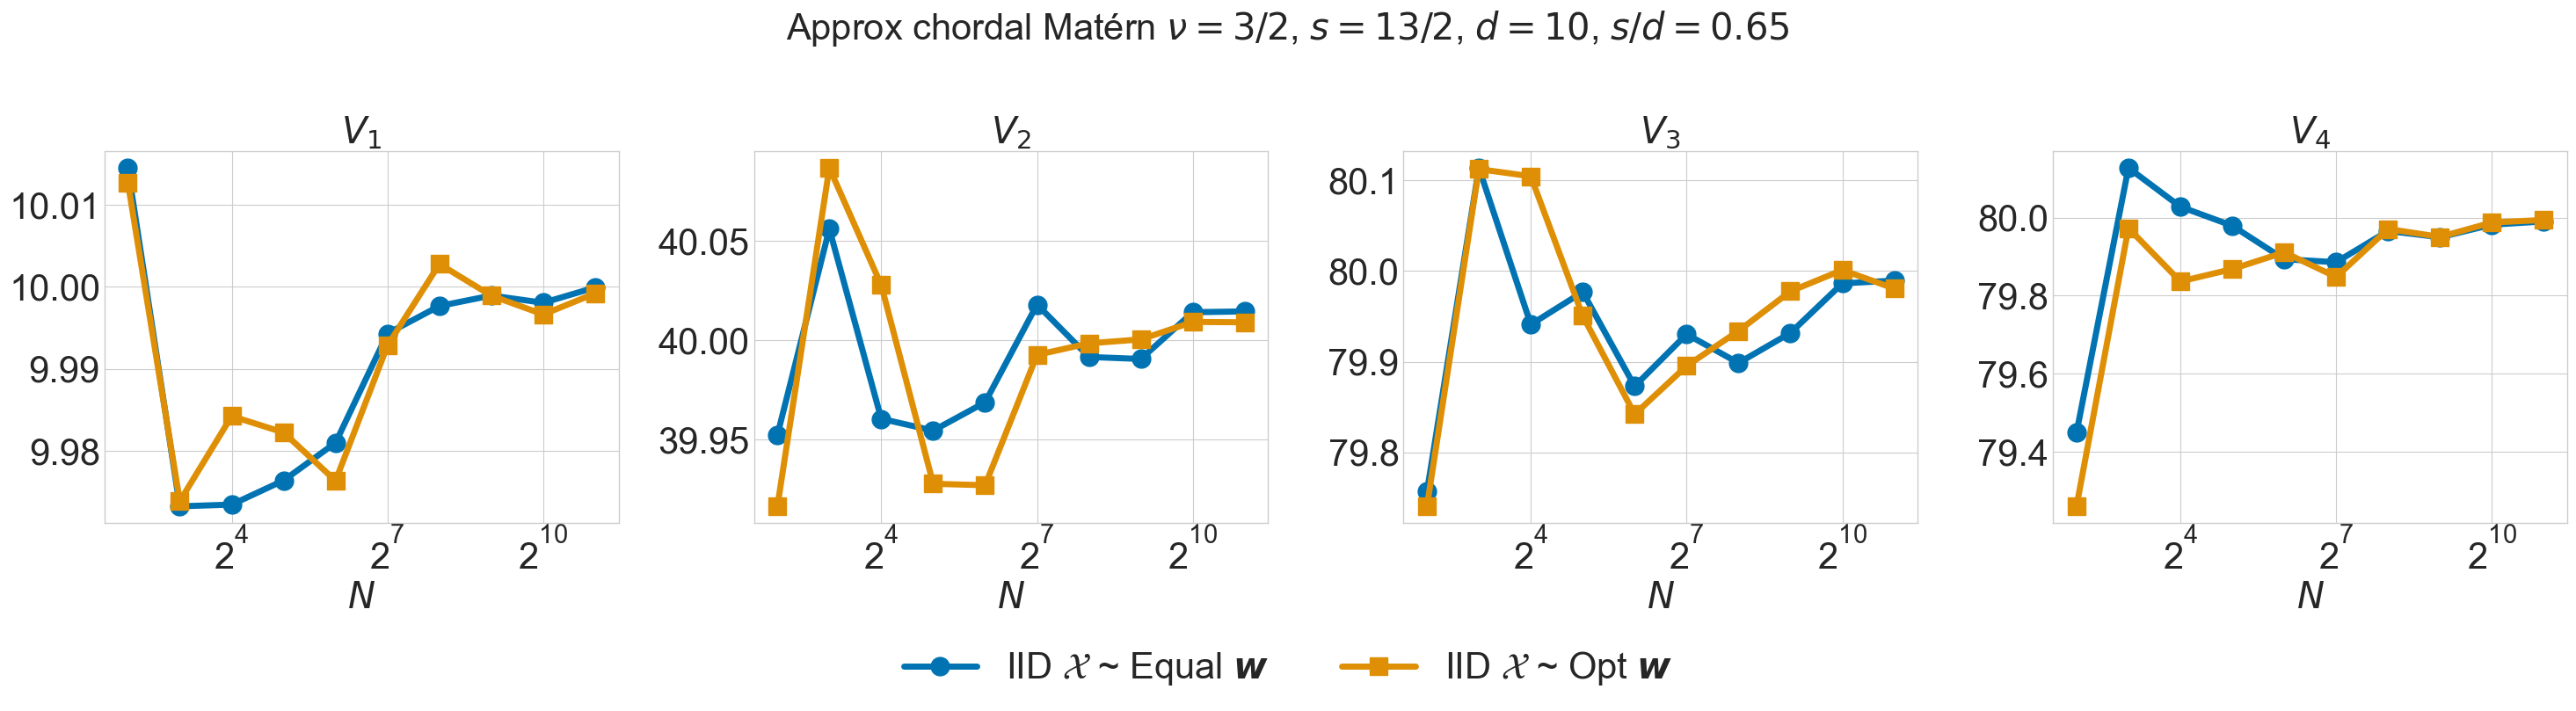

In [7]:
TK_hats_means = Tk_hats.mean(-2)
fig,ax = pyplot.subplots(nrows=1,ncols=p,figsize=(MPLP["PW"],MPLP["PW"]/p),sharex=True,sharey=False)
for i,(key,*_) in enumerate(genf_ld_optw_decomp):
    for k in range(1,p+1):
        ax[k-1].plot(N,TK_hats_means[i,:,k],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key if k==1 else None)
for k in range(1,p+1):
    ax[k-1].set_xscale("log",base=2)
    ax[k-1].set_xlabel(r"$N$")
    ax[k-1].set_title(r"$V_{%d}$"%k)
fig.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.1))
assert s==np.inf or s%1 in [0,1/2]
if s==np.inf:
    s_str = r"\infty"
elif s%1==0:
    s_str = r"%d"%s 
elif s%1==1/2:
    s_str = r"%d/2"%(2*s)
fig.suptitle(r"Approx chordal Matérn "+kernel.nu_str+r", $s = %s$"%s_str+r", $d=%d$"%d+r", $s/d = %.2f$"%(s/d))
fig.tight_layout()
# fig.savefig("./out/Vk.approx.%s.n%d.d%d.nu%s.png"%(body,n,d,nu),bbox_inches="tight")

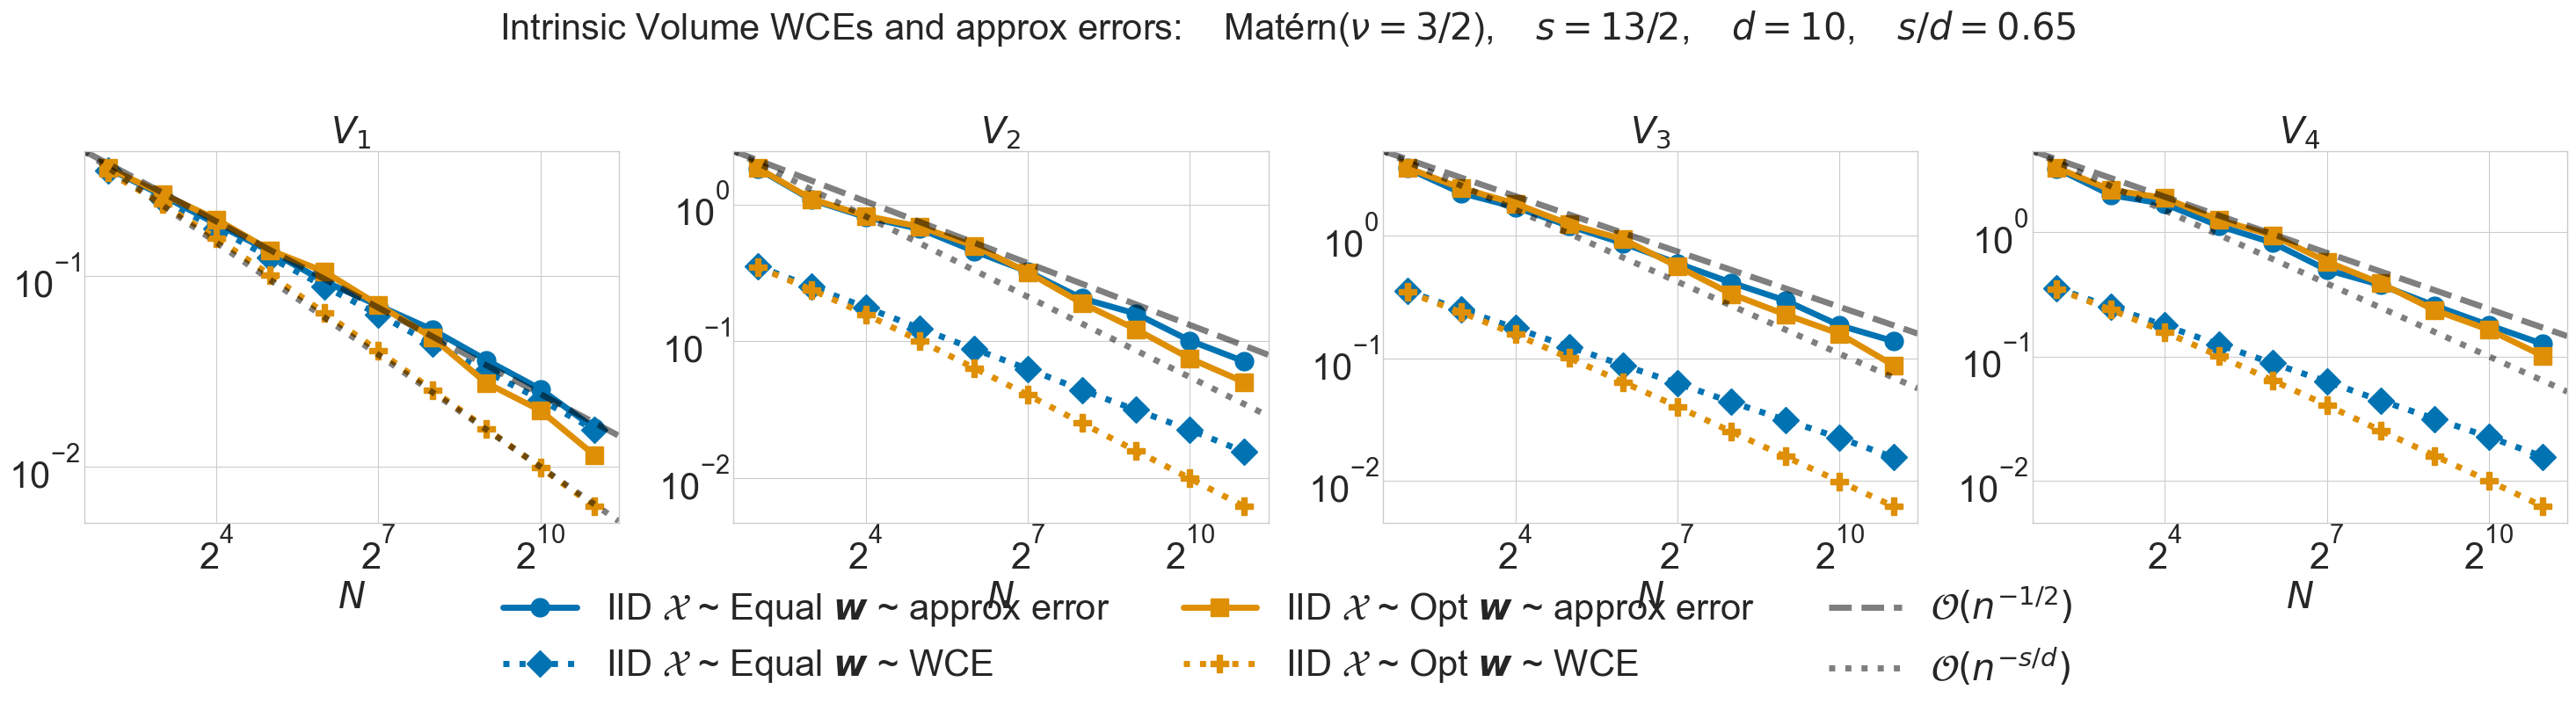

In [8]:
errors_mean = errors.mean(-2)
wces_means = wces.mean(-1)
fig,ax = pyplot.subplots(nrows=1,ncols=p,figsize=(MPLP["PW"],MPLP["PW"]/p),sharex=True,sharey=False)
for i,(key,*_) in enumerate(genf_ld_optw_decomp):
    for k in range(1,p+1):
        ax[k-1].plot(N,errors_mean[i,:,k],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key+" ~ approx error" if k==1 else None)
        ax[k-1].plot(N,wces_means[i],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i+len(genf_ld_optw_decomp)],label=key+ " ~ WCE" if k==1 else None,linestyle="dotted")
for k in range(1,p+1):
    ax[k-1].set_xscale("log",base=2)
    ax[k-1].set_yscale("log",base=10)
    ax[k-1].set_xlabel(r"$N$")
    ax[k-1].set_title(r"$V_{%d}$"%k)
    xmin,xmax = ax[k-1].get_xlim()
    ymin,ymax = ax[k-1].get_ylim()
    ax[k-1].set_xlim([xmin,xmax])
    ax[k-1].set_ylim([ymin,ymax])
    ax[k-1].axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,linestyle="dashed",label=r"$\mathcal{O}(n^{-1/2})$" if k==1 else None)
    ax[k-1].axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,linestyle="dotted",label=r"$\mathcal{O}(n^{-s/d})$" if k==1 else None)
fig.legend(frameon=False,ncols=3,loc="lower center",bbox_to_anchor=(.5,-.1))
assert s==np.inf or s%1 in [0,1/2]
if s==np.inf:
    s_str = r"\infty"
elif s%1==0:
    s_str = r"%d"%s 
elif s%1==1/2:
    s_str = r"%d/2"%(2*s)
fig.suptitle(r"Intrinsic Volume WCEs and approx errors:    Matérn(%s)"%kernel.nu_str+r",    $s = %s$"%s_str+r",    $d=%d$"%d+r",    $s/d = %.2f$"%(s/d))
fig.tight_layout()
fig.savefig("./out/Tk.error.%s.n%d.d%d.nu%s.png"%(body,n,d,nu),bbox_inches="tight")

In [9]:
wces_df = pd.DataFrame(wces.mean(-1).T,columns=[name for (name,*_) in genf_ld_optw_decomp])
wces_df['N'] = N
wces_df = wces_df.set_index('N')
print(r"WCEs")
wces_df

WCEs


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,0.354288,0.348848
8,0.250039,0.238080
16,0.177171,0.157613
32,0.124595,0.100871
64,0.088142,0.064044
128,0.062836,0.040553
256,0.044122,0.025295
512,0.031520,0.015860
1024,0.022548,0.009952


In [10]:
for k in range(1,p+1):
    Tk_hats_df_k = pd.DataFrame(Tk_hats[...,k].mean(-1).T,columns=[name for (name,*_) in genf_ld_optw_decomp])
    Tk_hats_df_k['N'] = N
    Tk_hats_df_k = Tk_hats_df_k.set_index('N')
    print(r"Tk_hats for k=%d with true value %.5e"%(k,Tk_true[k]))
    display(Tk_hats_df_k);

Tk_hats for k=1 with true value 1.00000e+01


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,10.014534,10.012740
8,9.973223,9.973849
16,9.973436,9.984235
32,9.976385,9.982230
64,9.980984,9.976340
128,9.994313,9.992850
256,9.997673,10.002795
512,9.998949,9.998933
1024,9.998068,9.996644


Tk_hats for k=2 with true value 4.00000e+01


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,39.952469,39.916618
8,40.055908,40.086573
16,39.960576,40.027667
32,39.954642,39.927945
64,39.968847,39.927215
128,40.017942,39.992665
256,39.991620,39.998474
512,39.990607,40.000444
1024,40.014088,40.009220


Tk_hats for k=3 with true value 8.00000e+01


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,79.756574,79.740392
8,80.113976,80.112552
16,79.941083,80.104679
32,79.976978,79.950599
64,79.872951,79.841997
128,79.930352,79.895301
256,79.898649,79.933993
512,79.931777,79.977708
1024,79.986458,80.001249


Tk_hats for k=4 with true value 8.00000e+01


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,79.448457,79.259788
8,80.127376,79.972816
16,80.027847,79.836215
32,79.978992,79.867934
64,79.893130,79.910874
128,79.885610,79.847722
256,79.965614,79.970739
512,79.949522,79.950366
1024,79.981752,79.987341


In [11]:
for k in range(1,p+1):
    errors_df_k = pd.DataFrame(errors[...,k].mean(-1).T,columns=[name for (name,*_) in genf_ld_optw_decomp])
    errors_df_k['N'] = N
    errors_df_k = errors_df_k.set_index('N')
    print(r"errors for k=%d"%k)
    display(errors_df_k);

errors for k=1


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,0.364788,0.367456
8,0.263482,0.268566
16,0.186801,0.197731
32,0.134134,0.136056
64,0.093554,0.105296
128,0.069948,0.070502
256,0.052291,0.047530
512,0.036253,0.027513
1024,0.025553,0.019772


errors for k=2


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,1.830151,1.853985
8,1.080774,1.093922
16,0.809275,0.825887
32,0.663360,0.688433
64,0.457311,0.500328
128,0.323609,0.319739
256,0.206260,0.190400
512,0.159350,0.122487
1024,0.101216,0.074966


errors for k=3


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,3.565852,3.591940
8,2.236708,2.456569
16,1.717084,1.833935
32,1.204961,1.248040
64,0.869360,0.935884
128,0.598483,0.565301
256,0.415671,0.335795
512,0.297339,0.228454
1024,0.186309,0.159446


errors for k=4


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,3.260339,3.294820
8,1.989986,2.190539
16,1.687921,1.881447
32,1.126142,1.254352
64,0.821279,0.943934
128,0.497955,0.579741
256,0.375926,0.387373
512,0.256187,0.235359
1024,0.178631,0.164194
